## MLS WS 2025/26 Exercise 4: Adversarial Patch Generation (30P)
*Adapted from an exercise created by Dennis Eisermann*

In this exercise, we will create and analyze [Adversarial Patches](https://arxiv.org/pdf/1712.09665) using the [Adversarial Robustness Toolbox](https://github.com/Trusted-AI/adversarial-robustness-toolbox?tab=readme-ov-file). These attacks are small patches that display input to deceive the decision process. Use the [Jupyter workbook](https://github.com/Trusted-AI/adversarial-robustness-toolbox/blob/main/notebooks/adversarial_patch/attack_adversarial_patch.ipynb) as a guideline, but for the implementation, use Pytorch [models](https://docs.pytorch.org/vision/main/models.html) and classes.

Note: We do not utilize Object Detectors because it requires too many computational resources. However, it is also possible to train against such models.

#### Learning Goals
- Understanding of flaws in the learned representation of classifiers
- Exploit weaknesses with adversarial patches
- Test the possibility to transfer attacks between different classifiers

### Task 1 – Classifier and Dataset Selection (5P)

First, select one classifier for the Adversarial Patch training and one classifier for testing adversarial transferability from the list below. Write your choice in the [Moodle course discussion thread](https://moodle.rwu.de/mod/forum/discuss.php?d=524#p715):

#### Classifiers:
- [MobileNetV3](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.mobilenet_v3_small.html#torchvision.models.mobilenet_v3_small)
- [VGG16](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.vgg16.html)
- [AlexNet](https://pytorch.org/hub/pytorch_vision_alexnet/)
- [ConvNext](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.convnext_tiny.html#torchvision.models.convnext_tiny)
- [Vision Transformer](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.vit_l_16.html#torchvision.models.vit_l_16)

#### Dataset:
You need a dataset with labels for the ImageNet classes. One option are the imagenet_stubs:

In [1]:
!pip install git+https://github.com/nottombrown/imagenet_stubs --upgrade
!pip install adversarial-robustness-toolbox

  Cloning https://github.com/nottombrown/imagenet_stubs to c:\users\iljas\appdata\local\temp\pip-req-build-i89sdsfe
  Resolved https://github.com/nottombrown/imagenet_stubs to commit 0b501276f54cbf45b8e1b67dccbdcbe51de88365
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/nottombrown/imagenet_stubs 'C:\Users\iljas\AppData\Local\Temp\pip-req-build-i89sdsfe'


In [2]:
# import imagenet_stubs
# import PIL.Image
# import matplotlib.pyplot as plt

# for image_path in imagenet_stubs.get_image_paths():
#     im = PIL.Image.open(image_path)
#     plt.axis('off')
#     plt.imshow(im, interpolation="nearest")
#     plt.show()

### Task 2 – Implementation (10P)

Load the classifier you chose pretrained on ImageNet. Prepare adjustable settings and the AdversarialPatchPytorch generator from the [toolbox](https://adversarial-robustness-toolbox.readthedocs.io/en/latest/modules/attacks/evasion.html#adversarial-patch-pytorchl). Remember to activate CUDA in order to speed up the process.

In [3]:
import torch
import torchvision as tv
import art.attacks.evasion as aae
import art.estimators.classification as aec
 
model_vgg = tv.models.vgg16(weights='IMAGENET1K_V1', progress=True)
model_vgg.eval()
vgg_tansforms = tv.models.VGG16_Weights.IMAGENET1K_V1.transforms()

import imagenet_stubs
import PIL.Image

image_batch = []

for image_path in imagenet_stubs.get_image_paths():
    img = PIL.Image.open(image_path)
    image_tensor = vgg_tansforms(img)
    image_batch.append(image_tensor)
    # prediction = model_vgg(torch.tensor(image_tensor.unsqueeze(0)))
    # label = int(torch.argmax(prediction).item())
    
training_batch = torch.stack(image_batch)

labels_tensor = torch.argmax(model_vgg(training_batch), dim=1)
target_class = 859  # Replace with your desired ImageNet class index
target_labels = torch.full_like(labels_tensor, target_class)  # Create target labels tensor

# Classifier
loss_fn = torch.nn.CrossEntropyLoss()
 
classifier = aec.PyTorchClassifier(
    model=model_vgg,
    loss=loss_fn,
    input_shape=(3, 224, 224),
    nb_classes=1000,
    clip_values=(-1, 1),
)

# Patch attack
attack = aae.AdversarialPatchPyTorch(
    estimator=classifier,
    patch_shape=(3, 50, 50),
    learning_rate=5.0,
    max_iter=500,
    batch_size=16,
    verbose=True,
)

patch, _ = attack.generate(x=training_batch, y=target_labels)

h:\Master CS\Repositories\ml_security_ws25\.venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Adversarial Patch PyTorch: 100%|██████████| 500/500 [03:20<00:00,  2.50it/s]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


(np.float64(-0.5), np.float64(49.5), np.float64(49.5), np.float64(-0.5))

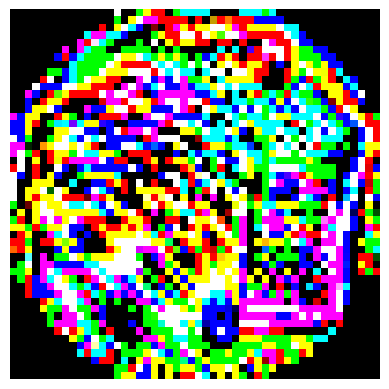

In [4]:
import matplotlib.pyplot as plt
import numpy as np

image = np.asarray(patch).transpose(1,2,0) # chw -> hwc

plt.imshow(image)
plt.axis('off')

### Task 3 – Evaluation (10P)

Generate two Adversarial Patches with two different target classes and max sizes using the dataset and the classifier. Evaluate the performance when applied to images. Print out your results and interpret the performances. You can try to improve the performance by adjusting the settings for the generator and repeat the generation step.

In [ ]:
# Assuming vgg_transforms is defined as in your notebook
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for image_path in imagenet_stubs.get_image_paths():
    img = PIL.Image.open(image_path)
    img = img.convert('RGB')
    
    # Convert to CHW NumPy array (as expected by apply_patch)
    img_np = np.array(img).transpose(2, 0, 1).astype(np.float32) / 255.0  # Normalize to [0,1]
    
    # Apply VGG normalization (mean/std)
    img_np = (img_np - np.array([0.485, 0.456, 0.406])[:, None, None]) / np.array([0.229, 0.224, 0.225])[:, None, None]
    
    img_np = np.expand_dims(img_np, axis=0)
    patched_image = attack.apply_patch(img_np, scale=1.0)
    
    prediction = model_vgg(torch.tensor(img_np, dtype=torch.float).cuda())
    predicted_class = int(torch.argmax(prediction).item())
    prediction_patched = model_vgg(torch.tensor(patched_image).cuda())
    predicted_patched_class = int(torch.argmax(prediction_patched).item())
    print('Original classe is: ',predicted_class, " Patched class is...", predicted_patched_class)

    # Denormalize for plotting
    patched_image = patched_image * std.numpy() + mean.numpy()
    patched_image = np.clip(patched_image, 0, 1)  # Clip to [0,1]

    patched_image = patched_image.squeeze(axis=0)
    
    # Transpose to HWC for plt.imshow
    patched_image = patched_image.transpose(1, 2, 0)
    
    plt.imshow(patched_image)
    plt.axis('off')
    plt.show()  # Add this to display each image

RuntimeError: Input type (double) and bias type (float) should be the same

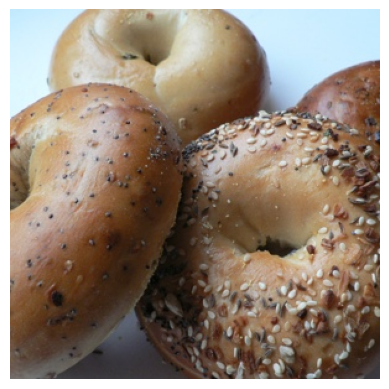

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..255.0].


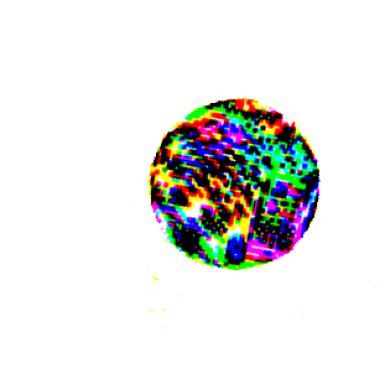

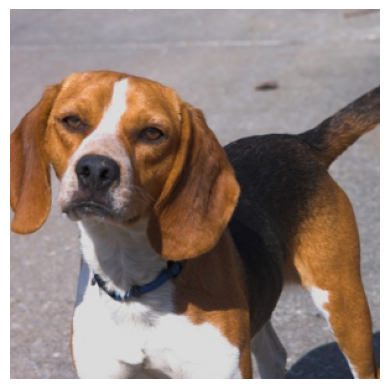

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..251.0].


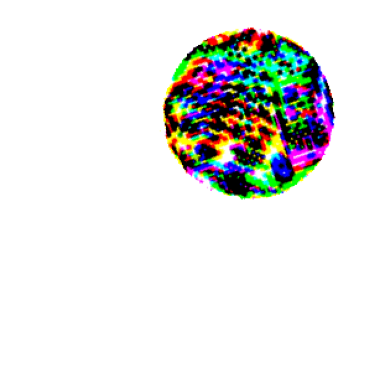

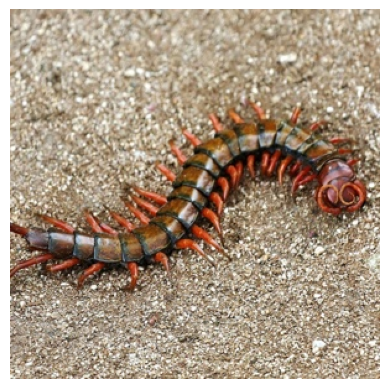

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..255.0].


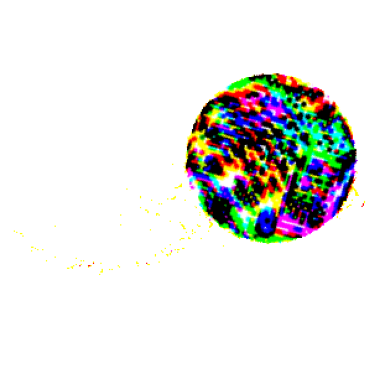

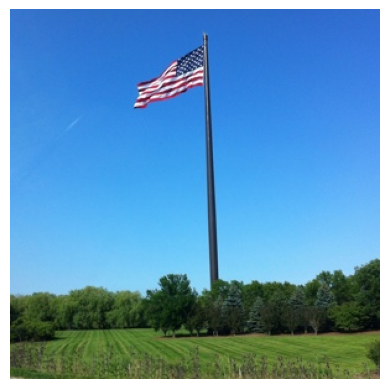

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..255.0].


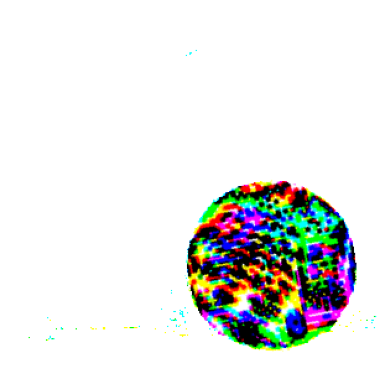

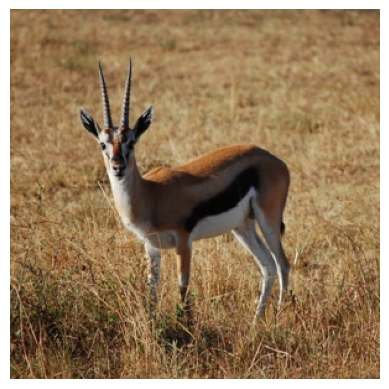

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..255.0].


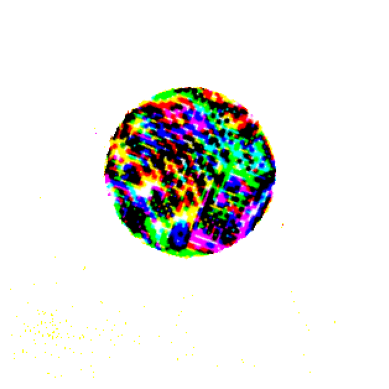

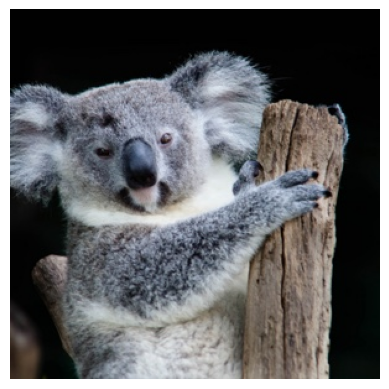

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..238.0].


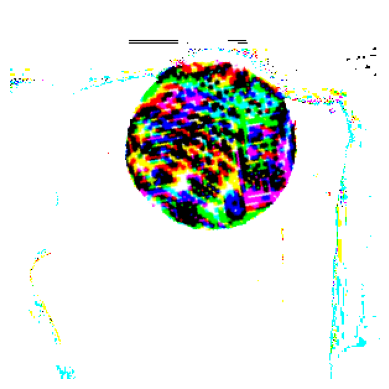

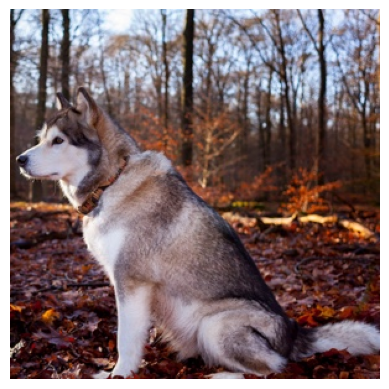

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..255.0].


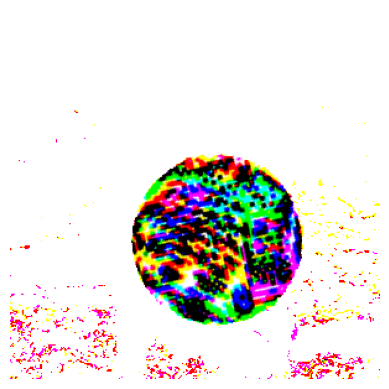

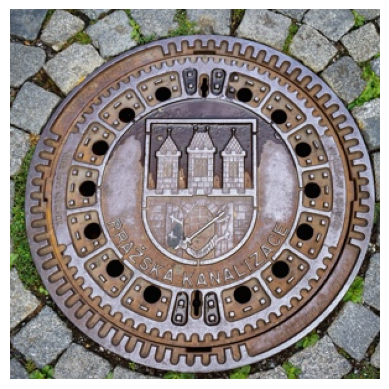

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..250.0].


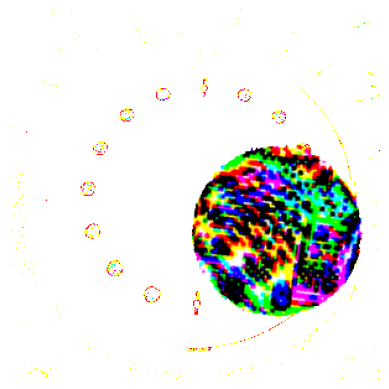

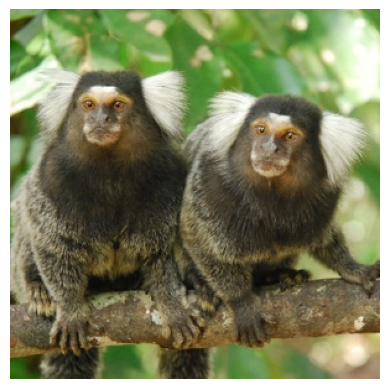

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..255.0].


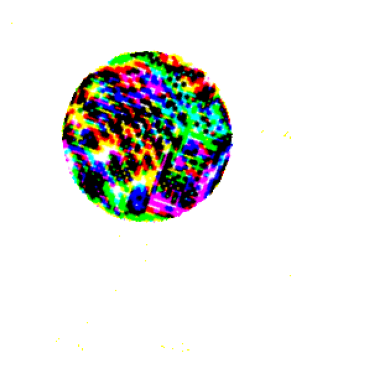

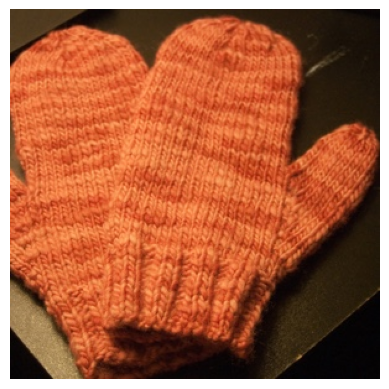

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..255.0].


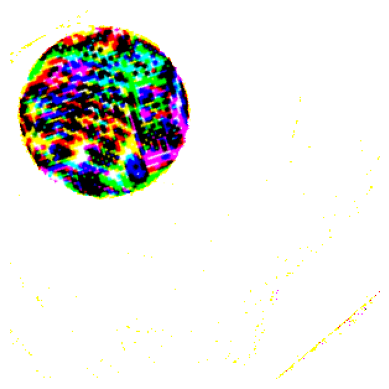

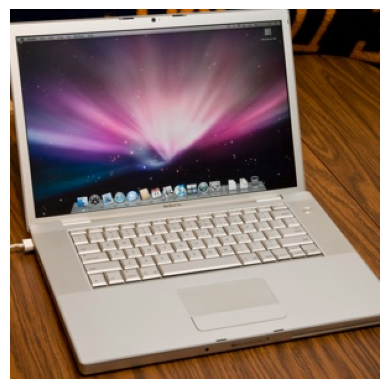

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..255.0].


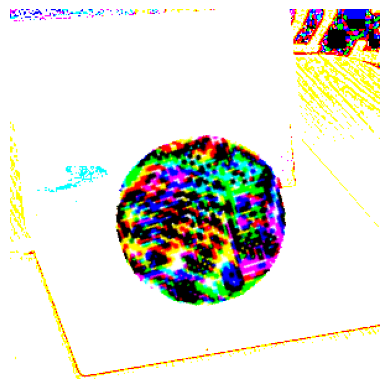

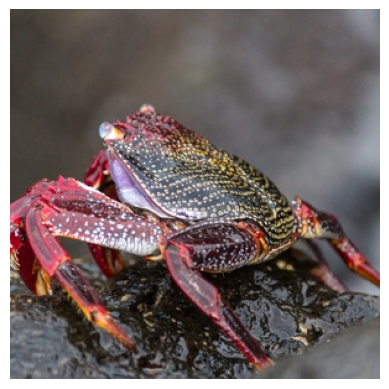

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..255.0].


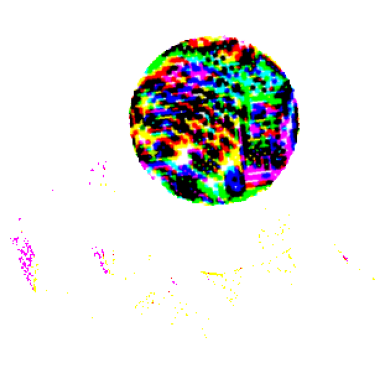

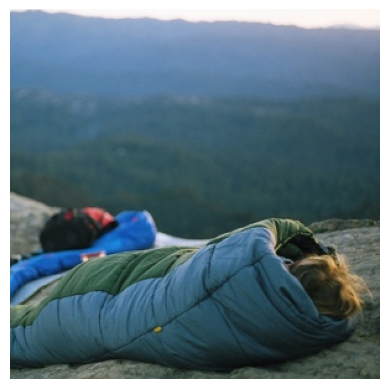

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..255.0].


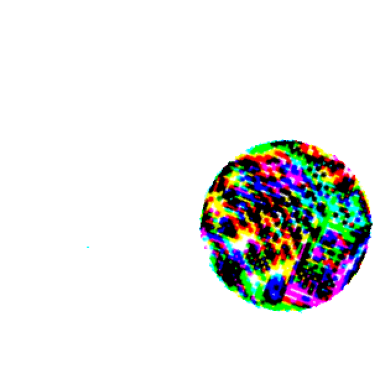

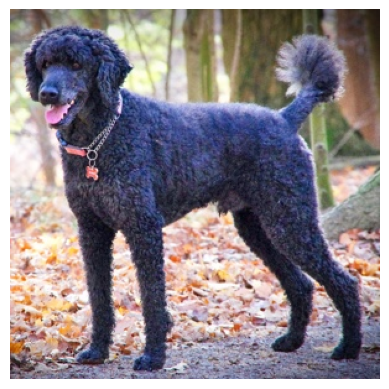

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..255.0].


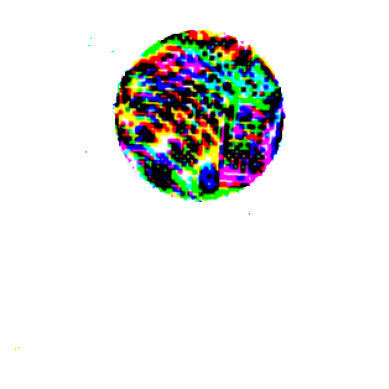

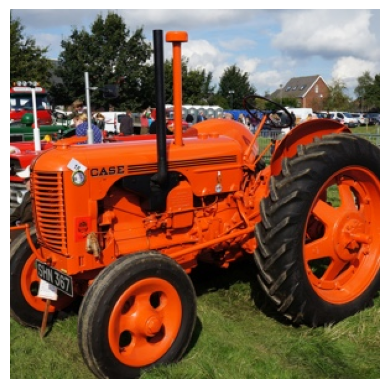

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..255.0].


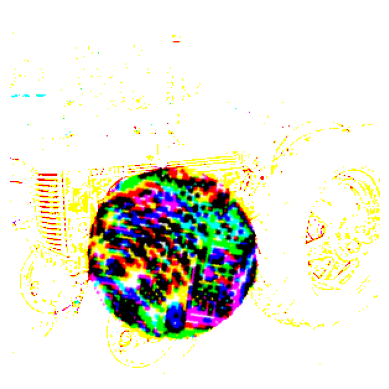

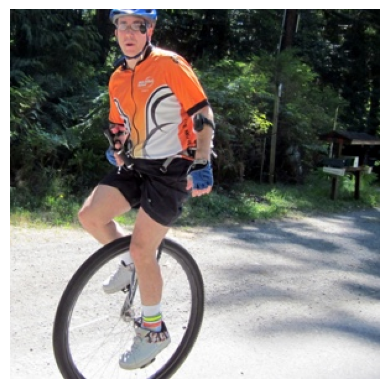

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..255.0].


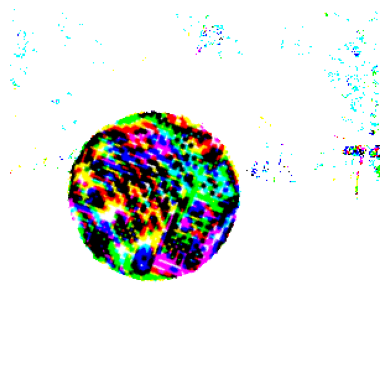

In [10]:
for image_path in imagenet_stubs.get_image_paths():
    img = PIL.Image.open(image_path)
    img = img.convert('RGB')
    img = np.array(img)
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    img = img.transpose(2,0,1) # hwc -> chw
    img = np.expand_dims(img, axis=0)
    patched_image = attack.apply_patch(img, scale=0.5)
    patched_image = patched_image.squeeze(axis=0)
    patched_image = patched_image.transpose(1,2,0)
    plt.imshow(patched_image)
    plt.axis('off')
    plt.show()

### Task 4 – Transferability (5P)

Now we want to see if the generated patches are transferable. Load another classifier from the list above and repeat the evaluation step with it. Evaluate the performance of your patches.